In [ ]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

In [1]:
import cma
import numpy as np
from numbers import Real
import torch
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
import os
import json
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *
from utils.load import get_segment_imgs, get_primitive_imgs
from utils.clipemb import CLIP_emb_from_IMG, CLIP_emb_from_TEXT, CLIP_emb_from_tensor
from utils.cma import clip_sol


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')
RW_PRIMITIVES_DIR = path.join(CONTENT_DIR, 'rw_primitives')
PRIMITIVE_DIR = path.join(CONTENT_DIR, 'primitives')

SEGMENT_IMGS = get_segment_imgs(SEGMENT_DIR, (WIDTH, HEIGHT))
RW_PRIMITIVES_IMGS = get_segment_imgs(RW_PRIMITIVES_DIR, (WIDTH, HEIGHT))
PRIMITIVE_IMGS = get_primitive_imgs(CONTENT_DIR, (WIDTH, HEIGHT))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [2]:
for prompt_text, elems in list(RW_PRIMITIVES_IMGS.items())[1:]:
    break

In [3]:
elems

{'cloud': <PIL.Image.Image image mode=RGBA size=300x129>,
 'moon': <PIL.Image.Image image mode=RGBA size=300x300>,
 'sky': <PIL.Image.Image image mode=RGBA size=300x200>}

In [4]:
prompt_text = 'a forest with a big fire and lots of smoke'

In [5]:
elem_list = [torch.tensor(np.asarray(e), dtype=torch.float32) / 255 for e in list(elems.values())]

In [6]:
prompt_embedding = CLIP_emb_from_TEXT(prompt_text)

In [7]:
def loss_fn(x0):
    rasterized_img = differentiable_rasterize(elem_list, x0[:, :3], x0[:, 3], (WIDTH, HEIGHT)).to(DEVICE)

    rasterized_emb = CLIP_emb_from_tensor(rasterized_img[:, :3, :, :])

    return torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)

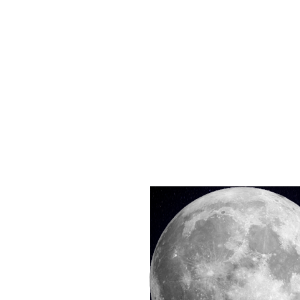

Iteration 23: Loss = 0.8327


In [ ]:
x0 = torch.ones((len(elem_list), 4)) * 0.5
x0[:, 0:1] = 0
x0[:, 2] = 0.2
x0[0, 3] = 0.5
x0[1, 3] = 1
x0[2, 3] = 0
x0.requires_grad_(True)

# Create an optimizer, here using SGD.
optimizer = torch.optim.SGD([x0], lr=0.01)
non_lin = torch.nn.Sigmoid()

# Optimization loop: we will perform gradient ascent on the loss by
# minimizing its negative.
num_iters = 1000
for i in range(num_iters):
    x0_sigmoid = non_lin(x0)
    optimizer.zero_grad()
    # Cosine similarity loss + regularization
    loss = (1 - loss_fn(x0_sigmoid))
    loss.backward()
    optimizer.step()
    if i % 1 == 0:
        with torch.no_grad():
            rasterized_img = differentiable_rasterize(elem_list, x0_sigmoid[:, :3], x0_sigmoid[:, 3], (WIDTH, HEIGHT))

        rasterized_img = rasterized_img.detach().cpu().squeeze().permute(1, 2, 0).numpy()
        clear_output(wait=True)  # Clear previous output
        display(Image.fromarray((rasterized_img * 255).astype(np.uint8)))
        print(f"Iteration {i}: Loss = {loss.item():.4f}")


cuda


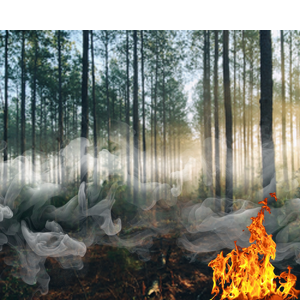

torch.Size([1, 3, 300, 300])
tensor([0.2759], device='cuda:0')


In [ ]:
prompt_embedding = CLIP_emb_from_TEXT(prompt_text)
x0 = np.ones((len(elems), 5))
x0[1, 4] = 0
x0[2, 4] = 0.5
x0[0, 4] = 1
x0[0, 2] = 0.5

x0[1, 0] = 0
x0[1, 1] = 1
x0[1, 2] = 1.2

img = rasterize_shapes_2(list(elems.values()), x0,(WIDTH, HEIGHT))
img = Image.alpha_composite(
        Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
        img
    ).convert("RGB")
display(img)
rasterized_imgs = np.stack([img], axis=0) # (population_size, 300, 300, 4)
rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE)
print(rasterized_imgs.shape)
rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)
losses = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)
print(losses)